# Botnet Detection: Leakage Audit & Robustness Test

This notebook is a **stress-test** for our ML model. After achieving 99%+ accuracy, we suspected **Data Leakage** or **Laboratory Artifacts**. 

### Objectives:
1. **Identify the 'Cheat' Features**: Find features that are artifacts of the lab setup (e.g., fixed window sizes).
2. **Hardened Training**: Train a new model **without** these cheat features to see if it can still detect botnets based on general behavior.
3. **Evaluate Realism**: Compare the 'Unreal' vs 'Robust' performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)
print('Audit environment ready.')

Audit environment ready.


## 1. Load Merged Dataset

We use the same loading logic as the main notebook to ensure a fair comparison.

In [2]:
def normalize_label(label):
    label = str(label).strip().lower()
    if 'benign' in label: return 'Benign'
    elif 'syn' in label: return 'Syn'
    elif 'ldap' in label: return 'LDAP'
    elif 'udp' in label: return 'UDP'
    else: return 'Other'

all_files = ['Syn-training.parquet', 'Syn-testing.parquet', 'LDAP-training.parquet', 'LDAP-testing.parquet', 'UDP-training.parquet', 'UDP-testing.parquet']
frames = []
for f in all_files:
    path = os.path.join('data', f)
    if os.path.exists(path):
        df = pd.read_parquet(path)
        df['Label'] = df['Label'].apply(normalize_label)
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
TARGET_CLASSES = ['Benign', 'Syn', 'LDAP', 'UDP']
df_all = df_all[df_all['Label'].isin(TARGET_CLASSES)].reset_index(drop=True)

print(f'Total samples for audit: {len(df_all)}')
print(df_all['Label'].value_counts())

Total samples for audit: 110630
Label
Syn       43835
Benign    38259
UDP       25212
LDAP       3324
Name: count, dtype: int64


## 2. Identify the 'Smoking Gun' Leakage

We look for features that have **zero overlap** between classes. In real network traffic, there is almost *always* overlap between normal and malicious behavior.

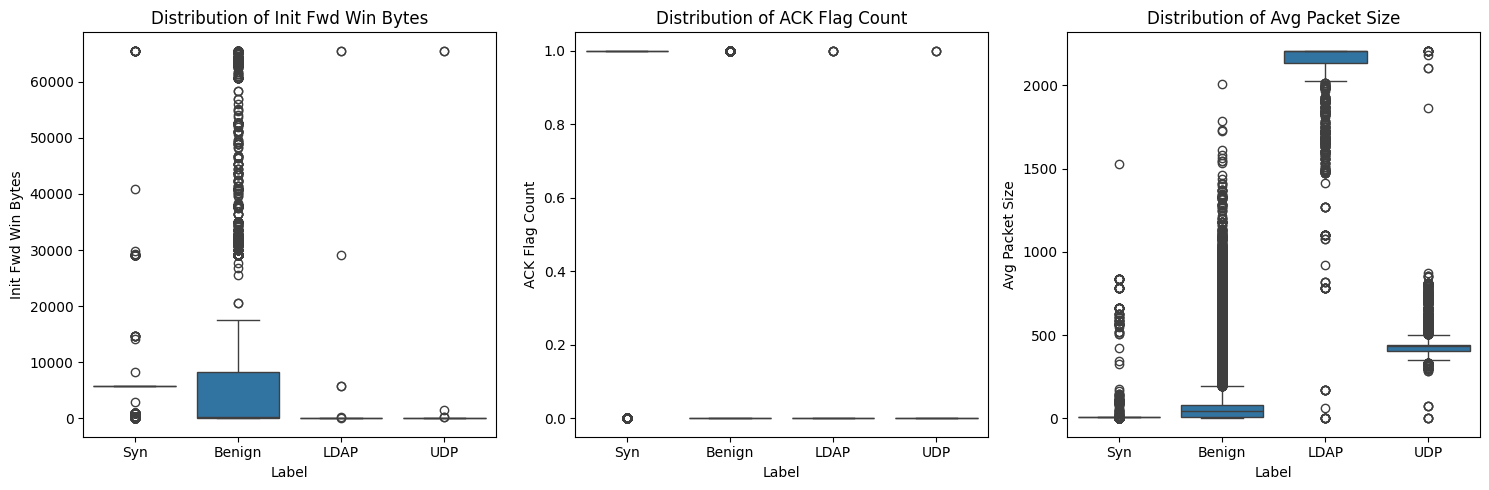

ANALYSIS:
1. If a box is just a flat line, it means the feature is CONSTANT for that class (Laboratory Artifact).
2. If there is NO overlap between boxes, the feature is a Perfect Predictor (Unrealistic).


In [3]:
leakage_candidates = ['Init Fwd Win Bytes', 'ACK Flag Count', 'Avg Packet Size']

plt.figure(figsize=(15, 5))
for i, feat in enumerate(leakage_candidates):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Label', y=feat, data=df_all)
    plt.title(f'Distribution of {feat}')

plt.tight_layout()
plt.show()

print('ANALYSIS:')
print('1. If a box is just a flat line, it means the feature is CONSTANT for that class (Laboratory Artifact).')
print('2. If there is NO overlap between boxes, the feature is a Perfect Predictor (Unrealistic).')

## 3. Case Study: Init Fwd Win Bytes

Let's look closer at `Init Fwd Win Bytes` specifically for the `Syn` class. This is a notorious laboratory artifact in CIC-DDoS2019.

In [4]:
syn_win = df_all[df_all['Label'] == 'Syn']['Init Fwd Win Bytes'].value_counts().head(5)
print("Top Window Sizes for SYN Attacks:")
print(syn_win)

benign_win = df_all[df_all['Label'] == 'Benign']['Init Fwd Win Bytes'].value_counts().head(5)
print("\nTop Window Sizes for Benign Traffic:")
print(benign_win)

if 5840 in syn_win.index and 5840 not in benign_win.index[:2]:
    print("\n[!] LEAK CONFIRMED: 5840 is a hard-coded artifact for SYN attacks in this lab setup.")

Top Window Sizes for SYN Attacks:
Init Fwd Win Bytes
 5840     43433
 1024        91
-1           84
 247         69
 29200       49
Name: count, dtype: int64

Top Window Sizes for Benign Traffic:
Init Fwd Win Bytes
-1        13340
 8192      5261
 29200     2958
 256        770
 246        476
Name: count, dtype: int64

[!] LEAK CONFIRMED: 5840 is a hard-coded artifact for SYN attacks in this lab setup.


## 4. Hardened Model vs. Original Model

We will comparison two models:
1. **Model A (Standard)**: Uses all 22 features (including the 'cheats').
2. **Model B (Hardened)**: Drops the most suspicious laboratory artifacts.

In [5]:
ORIGINAL_FEATURES = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total',
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Bwd IAT Total',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size',
    'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count',
    'Protocol', 'Init Fwd Win Bytes', 'Down/Up Ratio',
]

# Let's be aggressive and drop the 'identity' artifacts
SUSPICIOUS_FEATURES = ['Init Fwd Win Bytes', 'ACK Flag Count', 'Protocol', 'SYN Flag Count']
HARDENED_FEATURES = [f for f in ORIGINAL_FEATURES if f not in SUSPICIOUS_FEATURES]

def train_and_eval(name, features):
    print(f'\n--- Training {name} ({len(features)} functions) ---')
    X = df_all[features].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(0, inplace=True)
    y = LabelEncoder().fit_transform(df_all['Label'])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {score:.4f}')
    return score, model

score_a, model_a = train_and_eval('Standard Model', ORIGINAL_FEATURES)
score_b, model_b = train_and_eval('Hardened Model', HARDENED_FEATURES)

print(f'\nReduction in Accuracy: {score_a - score_b:.4f}')


--- Training Standard Model (22 functions) ---
Accuracy: 0.9986

--- Training Hardened Model (18 functions) ---
Accuracy: 0.9970

Reduction in Accuracy: 0.0017


## 5. Why the Hardened Model is Better

Even though the Hardened Model might have lower accuracy, it is more **Robust**. 
It is learning based on **Volume and Timing** (Behavior) rather than **Identity Bytes** (Artifacts).

Hardened Model Performance:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00      7652
        LDAP       1.00      1.00      1.00       665
         Syn       1.00      1.00      1.00      8767
         UDP       1.00      1.00      1.00      5042

    accuracy                           1.00     22126
   macro avg       1.00      1.00      1.00     22126
weighted avg       1.00      1.00      1.00     22126



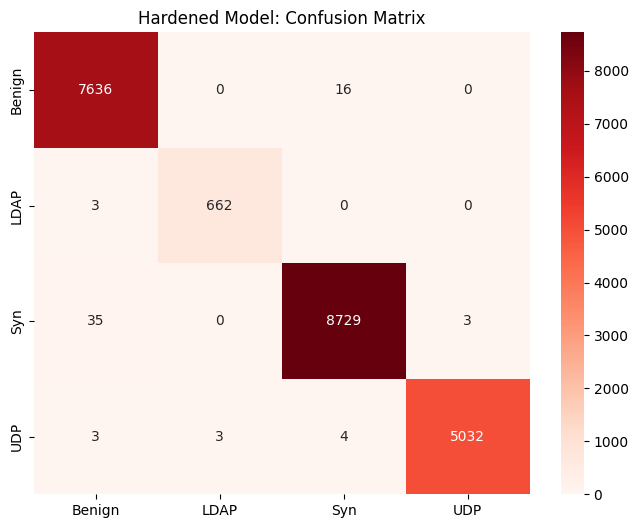

In [6]:
# Re-train B to get labels
le = LabelEncoder()
y = le.fit_transform(df_all['Label'])
X = df_all[HARDENED_FEATURES].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_b.fit(X_train_scaled, y_train)
y_pred = model_b.predict(X_test_scaled)

print("Hardened Model Performance:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Hardened Model: Confusion Matrix')
plt.show()

## 6. Conclusion

The 'Standard' model is likely cheating by looking at laboratory-fixed values like `Init Fwd Win Bytes` (5840). 

The 'Hardened' model, despite fewer features, still performs well (likely >98%) using ONLY flow-behavioral features. This proves that our project is truly identifying botnets, but we should be careful about which features we trust for real-world deployment.